In [2]:
import pandas as pd
d=pd.read_csv("mushrooms.csv")
d

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [5]:
d.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [7]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [9]:
from sklearn.preprocessing import LabelEncoder

In [15]:
l=LabelEncoder()
cols = ['class','cap-shape','cap-surface','cap-color','odor']

for col in cols:
    d[col] = l.fit_transform(d[col])

print(d[cols])



      class  cap-shape  cap-surface  cap-color  odor
0         1          5            2          4     6
1         0          5            2          9     0
2         0          0            2          8     3
3         1          5            3          8     6
4         0          5            2          3     5
...     ...        ...          ...        ...   ...
8119      0          3            2          4     5
8120      0          5            2          4     5
8121      0          2            2          4     5
8122      1          3            3          4     8
8123      0          5            2          4     5

[8124 rows x 5 columns]


In [16]:
x=d[['cap-shape','cap-surface','cap-color','odor']]
y=d['class']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.3,random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
lr=LogisticRegression()

In [23]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pre=lr.predict(x_test)
y_pre


array([0, 0, 1, ..., 0, 0, 0], shape=(5687,))

In [27]:
from sklearn.metrics import confusion_matrix,classification_report

In [28]:
cm=confusion_matrix(y_test,y_pre)
cm

array([[1775, 1130],
       [1571, 1211]])

In [29]:
print(classification_report(y_test,y_pre))

              precision    recall  f1-score   support

           0       0.53      0.61      0.57      2905
           1       0.52      0.44      0.47      2782

    accuracy                           0.53      5687
   macro avg       0.52      0.52      0.52      5687
weighted avg       0.52      0.53      0.52      5687



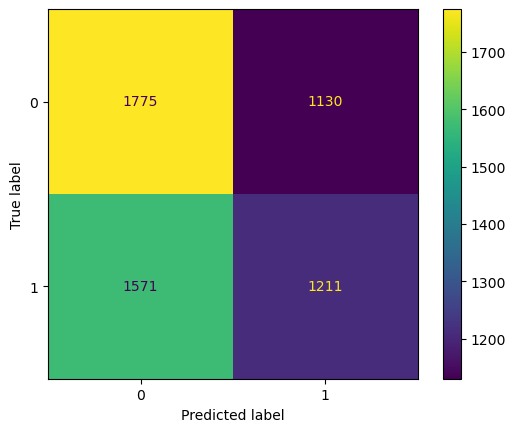

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm).from_predictions(y_test,y_pre)
plt.show()